In [1]:
# Mount Drive and verify all inputs exist
from google.colab import drive
drive.mount('/content/drive')

import os
import torch
import numpy as np

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

STGCN_CKPT       = '/content/drive/MyDrive/HRC_Research/checkpoints/stgcn_hri30_70_10_20/best_stgcn_hri30.pt'
CTRGCN_CKPT      = '/content/drive/MyDrive/HRC_Research/checkpoints/ctrgcn_hri30_70_10_20/best_ctrgcn_hri30.pt'

STGCN_TEST_DATA  = '/content/drive/MyDrive/HRC_Research/datasets/HRI30/HRI30_70_10_20/stgcn_format/test_data.npy'
STGCN_TEST_LABEL = '/content/drive/MyDrive/HRC_Research/datasets/HRI30/HRI30_70_10_20/stgcn_format/test_label.pkl'
CTRGCN_TEST_NPZ  = '/content/drive/MyDrive/HRC_Research/datasets/HRI30/HRI30_70_10_20/ctrgcn_format/HRI30_CS.npz'

STGCN_VAL_DATA  = '/content/drive/MyDrive/HRC_Research/datasets/HRI30/HRI30_70_10_20/stgcn_format/val_data.npy'
STGCN_VAL_LABEL = '/content/drive/MyDrive/HRC_Research/datasets/HRI30/HRI30_70_10_20/stgcn_format/val_label.pkl'
CTRGCN_VAL_NPZ  = '/content/drive/MyDrive/HRC_Research/datasets/HRI30/HRI30_70_10_20/ctrgcn_format/HRI30_CS.npz'

OUTPUT_DIR       = '/content/drive/MyDrive/HRC_Research/results/occlusion_benchmark'
os.makedirs(OUTPUT_DIR, exist_ok=True)

all_ok = True
checks = [
    ("ST-GCN checkpoint",   STGCN_CKPT),
    ("CTR-GCN checkpoint",  CTRGCN_CKPT),
    ("ST-GCN test data",    STGCN_TEST_DATA),
    ("ST-GCN test labels",  STGCN_TEST_LABEL),
    ("CTR-GCN test npz",    CTRGCN_TEST_NPZ),
    ("ST-GCN val data",     STGCN_VAL_DATA),
    ("ST-GCN val labels",   STGCN_VAL_LABEL),
]
print("\n--- File verification ---")
for name, path in checks:
    if os.path.exists(path):
        print(f"  OK  {name}")
    else:
        print(f"  MISSING  {name}: {path}")
        all_ok = False

if all_ok:
    print("\n[PASS] All inputs found. Proceed to Cell 2.")
else:
    print("\n[STOP] Fix missing files before continuing.")

Mounted at /content/drive
PyTorch version: 2.11.0+cu128
CUDA available: True
GPU: Tesla T4

--- File verification ---
  OK  ST-GCN checkpoint
  OK  CTR-GCN checkpoint
  OK  ST-GCN test data
  OK  ST-GCN test labels
  OK  CTR-GCN test npz
  OK  ST-GCN val data
  OK  ST-GCN val labels

[PASS] All inputs found. Proceed to Cell 2.


In [2]:
# Clone repos, patch, and load both models (70/10/20 Weights)
import os
import sys
import torch
import torch.nn as nn
from pathlib import Path

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

STGCN_DIR  = '/content/st-gcn'
CTRGCN_DIR = '/content/CTR-GCN'

if not os.path.exists(STGCN_DIR):
    os.system(f'git clone https://github.com/yysijie/st-gcn.git {STGCN_DIR}')
    print("ST-GCN cloned.")
else:
    print("ST-GCN already present.")

stgcn_io = Path(f'{STGCN_DIR}/torchlight/torchlight/io.py')
text = stgcn_io.read_text()
if 'weights_only=False' not in text:
    text = text.replace(
        'torch.load(weights_path)',
        'torch.load(weights_path, weights_only=False, map_location="cpu")'
    )
    stgcn_io.write_text(text)
    print("ST-GCN torch.load patch applied.")

os.system(f'pip install -e {STGCN_DIR}/torchlight -q')

if not os.path.exists(CTRGCN_DIR):
    os.system(f'git clone https://github.com/Uason-Chen/CTR-GCN.git {CTRGCN_DIR}')
    print("CTR-GCN cloned.")
else:
    print("CTR-GCN already present.")

os.system('pip install -q tensorboardX torchpack fvcore iopath yacs thop')
os.system(f'pip install -e {CTRGCN_DIR}/torchlight -q')

ctrgcn_util = Path(f'{CTRGCN_DIR}/torchlight/torchlight/util.py')
text = ctrgcn_util.read_text()
if 'PaviLogger = None' not in text:
    text = text.replace(
        'from torchpack.runner.hooks import PaviLogger',
        'try:\n    from torchpack.runner.hooks import PaviLogger\nexcept ImportError:\n    PaviLogger = None'
    )
    ctrgcn_util.write_text(text)
    print("CTR-GCN torchpack patch applied.")

print("\nLoading model architectures...")

sys.path.insert(0, STGCN_DIR)
from net.st_gcn import Model as STGCN_Model

stgcn_model = STGCN_Model(
    in_channels=3,
    num_class=30,
    dropout=0.5,
    edge_importance_weighting=True,
    graph_args={'layout': 'ntu-rgb+d', 'strategy': 'spatial'}
)

stgcn_ckpt = torch.load(
    '/content/drive/MyDrive/HRC_Research/checkpoints/stgcn_hri30_70_10_20/best_stgcn_hri30.pt',
    map_location='cpu', weights_only=False
)
stgcn_state = stgcn_ckpt['model_state_dict'] if isinstance(stgcn_ckpt, dict) and 'model_state_dict' in stgcn_ckpt else stgcn_ckpt
stgcn_state = {k[7:] if k.startswith('module.') else k: v for k, v in stgcn_state.items()}
stgcn_model.load_state_dict(stgcn_state, strict=True)
stgcn_model = stgcn_model.to(device)
stgcn_model.eval()
print("ST-GCN loaded (30 classes) - 70/10/20 Weights ✓")

sys.path.insert(0, CTRGCN_DIR)
from model.ctrgcn import Model as CTRGCN_Model

ctrgcn_model = CTRGCN_Model(
    num_class=30,
    num_point=25,
    num_person=1,
    graph='graph.ntu_rgb_d.Graph',
    graph_args={'labeling_mode': 'spatial'}
)

ctrgcn_ckpt = torch.load(
    '/content/drive/MyDrive/HRC_Research/checkpoints/ctrgcn_hri30_70_10_20/best_ctrgcn_hri30.pt',
    map_location='cpu', weights_only=False
)
ctrgcn_state = ctrgcn_ckpt['model_state_dict'] if isinstance(ctrgcn_ckpt, dict) and 'model_state_dict' in ctrgcn_ckpt else ctrgcn_ckpt
ctrgcn_state = {k[7:] if k.startswith('module.') else k: v for k, v in ctrgcn_state.items()}
ctrgcn_model.load_state_dict(ctrgcn_state, strict=True)
ctrgcn_model = ctrgcn_model.to(device)
ctrgcn_model.eval()
print("CTR-GCN loaded (30 classes) - 70/10/20 Weights ✓")

print("\n[PASS] Both NEW models ready. Proceed to Cell 3.")

Using device: cuda
ST-GCN cloned.
ST-GCN torch.load patch applied.
CTR-GCN cloned.
CTR-GCN torchpack patch applied.

Loading model architectures...
ST-GCN loaded (30 classes) - 70/10/20 Weights ✓
CTR-GCN loaded (30 classes) - 70/10/20 Weights ✓

[PASS] Both NEW models ready. Proceed to Cell 3.


In [3]:
# Load test data for both models
import numpy as np
import pickle

stgcn_test_data = np.load(STGCN_TEST_DATA)

with open(STGCN_TEST_LABEL, 'rb') as f:
    _, y_test = pickle.load(f)
stgcn_test_labels = np.array(y_test)

print(f"ST-GCN test data shape:   {stgcn_test_data.shape}")

npz = np.load(CTRGCN_TEST_NPZ)
ctrgcn_test_data   = npz['x_test']
ctrgcn_test_labels = npz['y_test']

assert (stgcn_test_labels == ctrgcn_test_labels).all(), "Label mismatch!"
print(f"[PASS] {stgcn_test_data.shape[0]} test samples loaded.")

ST-GCN test data shape:   (588, 3, 150, 25, 1)
[PASS] 588 test samples loaded.


In [4]:
# Occlusion Benchmark (N=30 Consensus Trials) - Generate Results

import torch
import numpy as np
import csv
import os

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

def apply_occlusion(data_np, occlusion_rate, seed=None):
    if occlusion_rate == 0.0:
        return data_np.copy()
    if seed is not None:
        np.random.seed(seed)
    data_out = data_np.copy()
    num_joints = data_out.shape[3]
    num_to_zero = max(1, int(round(num_joints * occlusion_rate)))
    joints_to_zero = np.random.choice(num_joints, num_to_zero, replace=False)
    data_out[:, :, :, joints_to_zero, :] = 0.0
    return data_out

def get_model_logits(model, data_np, batch_size=64):
    model.eval()
    all_logits = []
    N = data_np.shape[0]
    with torch.no_grad():
        for start in range(0, N, batch_size):
            end = min(start + batch_size, N)
            batch = torch.tensor(data_np[start:end], dtype=torch.float32).to(device)
            output = model(batch)
            all_logits.append(output.cpu().numpy())
    return np.concatenate(all_logits)

def softmax(logits):
    exp_x = np.exp(logits - np.max(logits, axis=1, keepdims=True))
    return exp_x / np.sum(exp_x, axis=1, keepdims=True)

def entropy(probs):
    return -np.sum(probs * np.log(probs + 1e-9), axis=1)

def consensus_fusion(logits_st, logits_ctr):
    probs_st = softmax(logits_st)
    probs_ctr = softmax(logits_ctr)
    H_st = entropy(probs_st)
    H_ctr = entropy(probs_ctr)
    W_st = np.exp(-H_st)
    W_ctr = np.exp(-H_ctr)
    sum_W = W_st + W_ctr
    W_st = W_st / sum_W
    W_ctr = W_ctr / sum_W
    probs_fused = W_st[:, None] * probs_st + W_ctr[:, None] * probs_ctr
    return np.argmax(probs_fused, axis=1)

# ═══ N=30 TRIALS ═══
OCCLUSION_RATES = [0.0, 0.10, 0.20, 0.30, 0.50]
NUM_TRIALS = 30
results = []

print("PHASE 4 - CONSENSUS LAYER BENCHMARK (N=30 TRIALS)")
print("===================================")

for rate in OCCLUSION_RATES:
    rate_label = f"{int(rate * 100)}%"
    n_trials = 1 if rate == 0.0 else NUM_TRIALS
    print(f"\n--- Occlusion rate: {rate_label} ({n_trials} trial(s)) ---")

    st_accs, ctr_accs, con_accs = [], [], []

    for trial in range(n_trials):
        seed = 42 + trial
        st_corr = apply_occlusion(stgcn_test_data, rate, seed=seed)
        ctr_corr = apply_occlusion(ctrgcn_test_data, rate, seed=seed)

        logits_st = get_model_logits(stgcn_model, st_corr)
        logits_ctr = get_model_logits(ctrgcn_model, ctr_corr)

        st_preds = np.argmax(logits_st, axis=1)
        ctr_preds = np.argmax(logits_ctr, axis=1)
        con_preds = consensus_fusion(logits_st, logits_ctr)

        N = stgcn_test_labels.shape[0]
        labels_np = stgcn_test_labels

        acc_st = 100.0 * (st_preds == labels_np).sum() / N
        acc_ctr = 100.0 * (ctr_preds == labels_np).sum() / N
        acc_con = 100.0 * (con_preds == labels_np).sum() / N

        st_accs.append(acc_st)
        ctr_accs.append(acc_ctr)
        con_accs.append(acc_con)

    st_mean, st_std = float(np.mean(st_accs)), float(np.std(st_accs))
    ctr_mean, ctr_std = float(np.mean(ctr_accs)), float(np.std(ctr_accs))
    con_mean, con_std = float(np.mean(con_accs)), float(np.std(con_accs))

    print(f"  -> MEAN: ST={st_mean:.1f}% (±{st_std:.2f}) | CTR={ctr_mean:.1f}% (±{ctr_std:.2f}) | CONSENSUS={con_mean:.1f}% (±{con_std:.2f})")

    results.append({
        'occlusion_rate': rate_label,
        'st_trial_accs': st_accs, 'ctr_trial_accs': ctr_accs, 'con_trial_accs': con_accs,
        'st_mean': st_mean, 'st_std': st_std,
        'ctr_mean': ctr_mean, 'ctr_std': ctr_std,
        'con_mean': con_mean, 'con_std': con_std
    })

# Save results to CSV
CSV_PATH = os.path.join(OUTPUT_DIR, 'consensus_benchmark_results_70_10_20.csv')
with open(CSV_PATH, 'w', newline='') as f:
    writer = csv.writer(f)
    writer.writerow(['occlusion_rate', 'st_mean', 'st_std', 'ctr_mean', 'ctr_std', 'con_mean', 'con_std', 'st_trials', 'ctr_trials', 'con_trials'])
    for r in results:
        writer.writerow([
            r['occlusion_rate'],
            f"{r['st_mean']:.4f}", f"{r['st_std']:.4f}",
            f"{r['ctr_mean']:.4f}", f"{r['ctr_std']:.4f}",
            f"{r['con_mean']:.4f}", f"{r['con_std']:.4f}",
            r['st_trial_accs'], r['ctr_trial_accs'], r['con_trial_accs']
        ])
print(f"\n[SAVED] CSV saved to Drive: {CSV_PATH}")

PHASE 4 - CONSENSUS LAYER BENCHMARK (N=30 TRIALS)

--- Occlusion rate: 0% (1 trial(s)) ---
  -> MEAN: ST=55.3% (±0.00) | CTR=67.7% (±0.00) | CONSENSUS=67.5% (±0.00)

--- Occlusion rate: 10% (30 trial(s)) ---
  -> MEAN: ST=43.5% (±7.30) | CTR=50.9% (±5.86) | CONSENSUS=54.2% (±5.47)

--- Occlusion rate: 20% (30 trial(s)) ---
  -> MEAN: ST=29.6% (±8.41) | CTR=33.9% (±5.89) | CONSENSUS=37.0% (±6.61)

--- Occlusion rate: 30% (30 trial(s)) ---
  -> MEAN: ST=23.5% (±8.19) | CTR=23.6% (±5.85) | CONSENSUS=27.9% (±5.80)

--- Occlusion rate: 50% (30 trial(s)) ---
  -> MEAN: ST=16.9% (±5.63) | CTR=13.3% (±3.51) | CONSENSUS=17.9% (±4.69)

[SAVED] CSV saved to Drive: /content/drive/MyDrive/HRC_Research/results/occlusion_benchmark/consensus_benchmark_results_70_10_20.csv


In [5]:
# ═══ VALIDATION CALIBRATION + STATS ═══
import numpy as np, pickle
from sklearn.metrics import roc_curve
import pandas as pd
from scipy import stats
from statsmodels.stats.multitest import multipletests
import ast, re

# 1. M1: Load VAL data (NEW PATHS)
stgcn_val_data = np.load(STGCN_VAL_DATA)
with open(STGCN_VAL_LABEL, 'rb') as f:
    _, y_val = pickle.load(f)
val_labels = np.array(y_val)

npz_val = np.load(CTRGCN_VAL_NPZ)
ctrgcn_val_data = npz_val['x_val']

# Run consensus on VAL set
logits_st_val = get_model_logits(stgcn_model, stgcn_val_data)
logits_ctr_val = get_model_logits(ctrgcn_model, ctrgcn_val_data)

probs_st_val = softmax(logits_st_val)
probs_ctr_val = softmax(logits_ctr_val)
H_st_val = entropy(probs_st_val)
H_ctr_val = entropy(probs_ctr_val)
W_st_val = np.exp(-H_st_val)
W_ctr_val = np.exp(-H_ctr_val)
norm_val = W_st_val + W_ctr_val
W_st_val /= norm_val
W_ctr_val /= norm_val
probs_fused_val = W_st_val[:, None] * probs_st_val + W_ctr_val[:, None] * probs_ctr_val

conf_val = np.max(probs_fused_val, axis=1)
preds_val = np.argmax(probs_fused_val, axis=1)
correct_val = (preds_val == val_labels).astype(int)
print(f"Val set consensus accuracy: {correct_val.mean()*100:.2f}%")

# Calibrate tau on VAL only
fpr, tpr, thresholds = roc_curve(correct_val, conf_val)
youden_j = tpr - fpr
tau_new = float(thresholds[np.argmax(youden_j)])
print(f"New tau (val-only, n=294): {tau_new:.4f}")

# Recompute SAFE-flagged precision on TEST set at 50% occlusion
st_occ50 = apply_occlusion(stgcn_test_data, 0.50, seed=42)
ctr_occ50 = apply_occlusion(ctrgcn_test_data, 0.50, seed=42)

logits_st50 = get_model_logits(stgcn_model, st_occ50)
logits_ctr50 = get_model_logits(ctrgcn_model, ctr_occ50)
probs_st50 = softmax(logits_st50)
probs_ctr50 = softmax(logits_ctr50)
H_st50 = entropy(probs_st50)
H_ctr50 = entropy(probs_ctr50)
W_st50 = np.exp(-H_st50) / (np.exp(-H_st50) + np.exp(-H_ctr50))
W_ctr50 = np.exp(-H_ctr50) / (np.exp(-H_st50) + np.exp(-H_ctr50))
probs_fused50 = W_st50[:, None] * probs_st50 + W_ctr50[:, None] * probs_ctr50

conf_test50 = np.max(probs_fused50, axis=1)
preds_test50 = np.argmax(probs_fused50, axis=1)
correct_t50 = (preds_test50 == stgcn_test_labels).astype(int)

flagged = conf_test50 >= tau_new
n_flagged = flagged.sum()
prec_at_50 = correct_t50[flagged].mean() if n_flagged > 0 else 0.0

print("\n=== COPY THESE VALUES INTO THE PAPER ===")
print(f" tau = {tau_new:.4f} (report as {tau_new:.2f})")
print(f" 50% occlusion SAFE precision = {prec_at_50:.1%}")

# Statistics (M2b)
def parse_accs(val):
    if isinstance(val, list): return val
    if not isinstance(val, str): return [val]
    val = re.sub(r'(np|torch)\.float(?:32|64)?\(([^)]+)\)', r'\2', val)
    val = re.sub(r'float\(([^)]+)\)', r'\1', val)
    if ',' not in val and ' ' in val: val = val.replace(' ', ', ')
    return ast.literal_eval(val)

# Load Phase3 n=30 baseline (NEW PATH)
BASE_CSV = '/content/drive/MyDrive/HRC_Research/results/occlusion_benchmark/occlusion_results_n30_70_10_20.csv'
df_base = pd.read_csv(BASE_CSV)

# Load Phase4 n=30 consensus (NEW PATH)
CON_CSV = '/content/drive/MyDrive/HRC_Research/results/occlusion_benchmark/consensus_benchmark_results_70_10_20.csv'
df_con = pd.read_csv(CON_CSV)

def cohen_d(x, y):
    nx, ny = len(x), len(y)
    pooled = np.sqrt(((nx-1)*np.std(x,ddof=1)**2 + (ny-1)*np.std(y,ddof=1)**2) / (nx+ny-2))
    return (np.mean(x) - np.mean(y)) / pooled if pooled > 0 else 0.0

p_values = []
print(f"\n{'Rate':<6} {'Mean Gain':>10} {'p (raw)':>9} {'d':>7}")
print("-" * 40)

for _, row in df_base.iterrows():
    rate_key = row['occlusion_rate']
    if rate_key == '0%': continue
    stgcn_accs = parse_accs(row['stgcn_accs'])
    ctrgcn_accs = parse_accs(row['ctrgcn_accs'])
    con_row = df_con[df_con['occlusion_rate'] == rate_key].iloc[0]
    con_accs = parse_accs(str(con_row['con_trials']))
    best_bl = [max(s, c) for s, c in zip(stgcn_accs, ctrgcn_accs)]
    _, p_raw = stats.ttest_rel(con_accs, best_bl)
    d = cohen_d(con_accs, best_bl)
    p_values.append((rate_key, p_raw))
    gain = np.mean(con_accs) - np.mean(best_bl)
    print(f"{rate_key:<6} {gain:>+9.2f}pp {p_raw:>9.3f} {d:>7.3f}")

if p_values:
    keys = [x[0] for x in p_values]
    pvals = [x[1] for x in p_values]
    reject, p_holm, _, _ = multipletests(pvals, method='holm')
    print("\nHolm-corrected p-values:")
    for k, ph, rej in zip(keys, p_holm, reject):
        sig = "SIGNIFICANT" if rej else "not significant"
        print(f" {k}: p_holm={ph:.3f} -> {sig}")

Val set consensus accuracy: 70.41%
New tau (val-only, n=294): 0.7080

=== COPY THESE VALUES INTO THE PAPER ===
 tau = 0.7080 (report as 0.71)
 50% occlusion SAFE precision = 41.4%

Rate    Mean Gain   p (raw)       d
----------------------------------------
10%        +2.72pp     0.000   0.487
20%        +0.88pp     0.260   0.141
30%        +0.28pp     0.638   0.045
50%        -0.23pp     0.661  -0.045

Holm-corrected p-values:
 10%: p_holm=0.000 -> SIGNIFICANT
 20%: p_holm=0.780 -> not significant
 30%: p_holm=1.000 -> not significant
 50%: p_holm=1.000 -> not significant


Reading benchmark data directly from Drive...


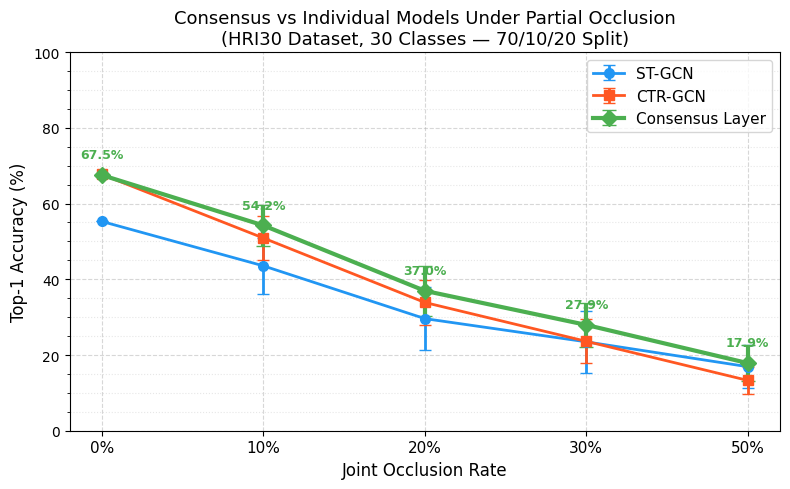


[SAVED] Plot successfully saved to Drive: /content/drive/MyDrive/HRC_Research/results/occlusion_benchmark/consensus_vs_individual_70_10_20.png


In [6]:
# Plot Consensus vs Individual Models (Independent CSV Reader)
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import pandas as pd
import os

OUTPUT_DIR = '/content/drive/MyDrive/HRC_Research/results/occlusion_benchmark'

CSV_PATH = os.path.join(OUTPUT_DIR, 'consensus_benchmark_results_70_10_20.csv')

if not os.path.exists(CSV_PATH):
    raise FileNotFoundError(f"Cannot find CSV at {CSV_PATH}. Make sure Cell 4 ran successfully!")

print("Reading benchmark data directly from Drive...")
df = pd.read_csv(CSV_PATH)

occlusion_labels = df['occlusion_rate'].tolist()
st_means = df['st_mean'].tolist()
ctr_means = df['ctr_mean'].tolist()
con_means = df['con_mean'].tolist()

st_stds = df['st_std'].tolist()
ctr_stds = df['ctr_std'].tolist()
con_stds = df['con_std'].tolist()

x = list(range(len(occlusion_labels)))

fig, ax = plt.subplots(figsize=(8, 5))

ax.errorbar(x, st_means, yerr=st_stds, label='ST-GCN', marker='o', color='#2196F3', linewidth=2, markersize=7, capsize=4)
ax.errorbar(x, ctr_means, yerr=ctr_stds, label='CTR-GCN', marker='s', color='#FF5722', linewidth=2, markersize=7, capsize=4)
ax.errorbar(x, con_means, yerr=con_stds, label='Consensus Layer', marker='D', color='#4CAF50', linewidth=3, markersize=8, capsize=5)

for i, con in enumerate(con_means):
    ax.annotate(f'{con:.1f}%', xy=(i, con), xytext=(0, 12), textcoords='offset points', ha='center', fontsize=9, color='#4CAF50', fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(occlusion_labels, fontsize=11)
ax.set_xlabel('Joint Occlusion Rate', fontsize=12)
ax.set_ylabel('Top-1 Accuracy (%)', fontsize=12)
ax.set_title('Consensus vs Individual Models Under Partial Occlusion\n(HRI30 Dataset, 30 Classes — 70/10/20 Split)', fontsize=13)
ax.legend(fontsize=11, loc='upper right')
ax.yaxis.set_minor_locator(mticker.AutoMinorLocator())
ax.grid(True, which='major', linestyle='--', alpha=0.5)
ax.grid(True, which='minor', linestyle=':', alpha=0.3)

min_val = min(min(st_means), min(ctr_means), min(con_means))
ax.set_ylim(max(0, min_val - 15), 100)

plt.tight_layout()

# UPDATED PATH for new plot
PLOT_PATH = os.path.join(OUTPUT_DIR, 'consensus_vs_individual_70_10_20.png')
plt.savefig(PLOT_PATH, dpi=150, bbox_inches='tight')
plt.show()

print(f"\n[SAVED] Plot successfully saved to Drive: {PLOT_PATH}")

In [7]:
# Final Summary Table (Independent CSV Reader)
import pandas as pd
import os

OUTPUT_DIR = '/content/drive/MyDrive/HRC_Research/results/occlusion_benchmark'

CSV_PATH = os.path.join(OUTPUT_DIR, 'consensus_benchmark_results_70_10_20.csv')

if not os.path.exists(CSV_PATH):
    raise FileNotFoundError(f"Cannot find CSV at {CSV_PATH}. Make sure Cell 4 ran successfully!")

df = pd.read_csv(CSV_PATH)

print("\n" + "=" * 75)
print("FINAL SUMMARY TABLE: CONSENSUS LAYER VS BASELINES (70/10/20)")
print("=" * 75)
print(f"{'Occlusion':<12} | {'ST-GCN':>10} | {'CTR-GCN':>10} | {'Consensus':>11} | {'Improvement':>13}")
print("-" * 75)

for index, row in df.iterrows():
    occ = str(row['occlusion_rate'])
    st = float(row['st_mean'])
    ctr = float(row['ctr_mean'])
    con = float(row['con_mean'])
    best_baseline = max(st, ctr)
    improvement = con - best_baseline

    print(f"{occ:<12} | {st:>9.2f}% | {ctr:>9.2f}% | {con:>10.2f}% | {improvement:>11.2f} pp")

print("=" * 75)


FINAL SUMMARY TABLE: CONSENSUS LAYER VS BASELINES (70/10/20)
Occlusion    |     ST-GCN |    CTR-GCN |   Consensus |   Improvement
---------------------------------------------------------------------------
0%           |     55.27% |     67.69% |      67.52% |       -0.17 pp
10%          |     43.55% |     50.90% |      54.22% |        3.33 pp
20%          |     29.61% |     33.88% |      36.96% |        3.08 pp
30%          |     23.48% |     23.61% |      27.95% |        4.34 pp
50%          |     16.92% |     13.29% |      17.86% |        0.95 pp
